# Spectral Filtering + VAW (Vovk-Azoury-Warmuth)

This notebook presents a practical implementation of **Spectral Filtering** combined with the **VAW (Vovk-Azoury-Warmuth)** online learning algorithm for sequential prediction in linear dynamical systems.

The objective is to demonstrate how temporal dynamics can be represented in a compact spectral basis using Hankel matrices and Singular Value Decomposition (SVD), while an online second-order learning algorithm adaptively estimates the system behavior over time.

The notebook is organized into the following steps:

1. Simulation of a Linear Dynamical System (LDS)
2. Construction of the Hankel matrix
3. Spectral decomposition using SVD
4. Extraction of spectral features
5. Online learning using the VAW algorithm
6. Sequential prediction and evaluation
7. Visualization of predictions and spectral filters

This implementation is inspired by modern approaches in:

- Online Control
- Online Convex Optimization
- Spectral Filtering
- State Space Models
- Adaptive Filtering
- Sequential Prediction

The methodology follows ideas presented in the literature of Online Nonstochastic Control and Spectral Learning for Linear Dynamical Systems.

# Importing Libraries

In this section, we import the fundamental libraries required for the implementation.

The project relies primarily on:

- `NumPy` for numerical linear algebra operations;
- `Matplotlib` for visualization and analysis of the results.

Linear dynamical systems, spectral decompositions, and online learning algorithms are fundamentally matrix-based methods. Therefore, efficient numerical computation is essential.

The use of NumPy is particularly important because:

- state-space models are naturally represented using matrices;
- Singular Value Decomposition (SVD) is a linear algebra operation;
- online optimization algorithms frequently require vectorized computations.

Matplotlib is used to visually interpret:

- the prediction quality;
- the temporal behavior of the system;
- the learned spectral filters.

Visualization is important because spectral methods are highly geometric in nature. Many insights become clearer when observing the filters and predictions graphically.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generating a Linear Dynamical System

In this section, we simulate a simple Linear Dynamical System (LDS).

The purpose of this step is to generate sequential data with temporal dependencies, allowing us to test spectral filtering and online learning techniques.

The system follows the standard state-space representation:

\[
x_{t+1} = Ax_t + Bu_t + w_t
\]

\[
y_t = Cx_t
\]

where:

- \(x_t\) is the hidden state;
- \(u_t\) is the control/input signal;
- \(w_t\) is a noise perturbation;
- \(y_t\) is the observed output.

The matrices:

- \(A\) define the system dynamics;
- \(B\) define how inputs affect the state;
- \(C\) define how the hidden state is observed.

The chosen system is intentionally stable because spectral filtering techniques are easier to analyze and interpret in stable systems.

Noise is added to simulate realistic conditions. In practical systems, measurements and dynamics are rarely noise-free due to:

- sensor inaccuracies;
- external disturbances;
- model mismatch;
- environmental uncertainties.

The generated output signal will later be transformed into a spectral representation.

In [17]:
# ============================================================
# 1. Generating a simple linear dynamical system
# ============================================================

np.random.seed(42)

T = 300

# Stable linear system
A = np.array([[0.95]])
B = np.array([[0.5]])
C = np.array([[1.0]])

x = np.zeros((T + 1, 1))
u = np.random.randn(T, 1) * 0.5
y = np.zeros((T, 1))

for t in range(T):
    noise = 0.05 * np.random.randn(1)
    x[t + 1] = A @ x[t] + B @ u[t] + noise
    y[t] = C @ x[t]

# Constructing the Hankel Matrix

This section constructs a Hankel matrix from the observed signal.

The Hankel matrix is one of the most important structures in spectral filtering and system identification.

A Hankel matrix has the form: $H_{ij} = h_{i+j}$

which means that each anti-diagonal contains constant values.

The purpose of the Hankel matrix is to capture the temporal structure and memory of the system.

Linear dynamical systems exhibit strong temporal correlations because future outputs depend on past states and inputs. The Hankel structure compactly organizes these temporal dependencies.

Conceptually, the Hankel matrix converts a one-dimensional temporal signal into a higher-dimensional representation where:

- rows represent temporal shifts;
- columns represent overlapping temporal windows.

This transformation is crucial because spectral methods operate more effectively on structured temporal representations.

Without this transformation, extracting dominant temporal modes from the signal would be significantly more difficult.

In [18]:
# ============================================================
# 2. Constructing the Hankel matrix
# ============================================================

def hankel_matrix(signal, hankel_size):
    """
    Creates a temporal Hankel matrix.
    """
    N = len(signal) - hankel_size

    H = np.zeros((hankel_size, N))

    for i in range(hankel_size):
        H[i] = signal[i:i + N].flatten()

    return H

hankel_size = 30

H = hankel_matrix(y, hankel_size)

# Spectral Decomposition using Singular Value Decomposition (SVD)

In this section, we apply Singular Value Decomposition (SVD) to the Hankel matrix.

The decomposition is given by:


$H = U \Sigma V^\top$

where:
- $U$ contains the left singular vectors;
- $\Sigma$ is the diagonal matrix containing the singular values;
- $V^\top$ contains the right singular vectors.

The objective of this step is to identify the dominant spectral modes of the temporal dynamics.

The singular vectors represent directions of maximum energy and variance in the temporal signal.

The singular values indicate how important each mode is.

The key idea behind spectral filtering is that many dynamical systems can be approximated using only a few dominant modes.

Instead of learning the entire temporal history explicitly, we project the signal onto a low-dimensional spectral basis.

This highly reduces:

- computational complexity;
- noise sensitivity;
- dimensionality.

The selected singular vectors become the spectral filters used later for feature extraction.

In [ ]:
# ============================================================
# 3. Spectral decomposition
# ============================================================

# SVD da Hankel
U, S, Vt = np.linalg.svd(H, full_matrices=False)

# Number of spectral filters to keep 
# #TODO: What's the best way to choose this? Maybe based on the singular values? Or maybe based on the reconstruction error? Or maybe based on the application? For example, if we want to do denoising, we might want to keep more filters. If we want to do dimensionality reduction, we might want to keep fewer filters.)
# I think we can use elbow method to choose the number of filters. We can plot the singular values and look for the elbow point where the singular values start to decay rapidly. This point can be a good choice for the number of filters to keep.
k = 5

spectral_filters = U[:, :k]

print("Filtros espectrais:")
print(spectral_filters.shape)

Filtros espectrais:
(30, 5)


In [10]:
# ============================================================
# 4. Building spectral features
# ============================================================

def spectral_features(signal, filters):
    """
    Projects temporal windows onto spectral filters.
    """

    h = filters.shape[0]
    N = len(signal) - h

    X = []

    for t in range(N):

        window = signal[t:t + h].flatten()

        feats = filters.T @ window

        X.append(feats)

    return np.array(X)

X_spec = spectral_features(y, spectral_filters)

# Future targets
y_target = y[hankel_size:].flatten()

In [11]:
# ============================================================
# 5. VAW (Vovk-Azoury-Warmuth)
# ============================================================

class VAWRegressor:
    """
    Simple implementation of the VAW algorithm.
    """

    def __init__(self, dim, alpha=1.0):

        self.dim = dim

        # Covariance matrix
        self.A = alpha * np.eye(dim)

        # Accumulated target vector
        self.b = np.zeros(dim)

        self.w = np.zeros(dim)

    def predict(self, x):

        return self.w @ x

    def update(self, x, y):

        # Recursive Least Squares-style update

        self.A += np.outer(x, x)

        self.b += y * x

        self.w = np.linalg.solve(self.A, self.b)

In [12]:
# ============================================================
# 6. Online learning
# ============================================================

model = VAWRegressor(dim=k, alpha=1.0)

preds = []

for t in range(len(X_spec)):

    x_t = X_spec[t]
    y_t = y_target[t]

    y_pred = model.predict(x_t)

    preds.append(y_pred)

    model.update(x_t, y_t)

preds = np.array(preds)


Online MSE: 0.116049


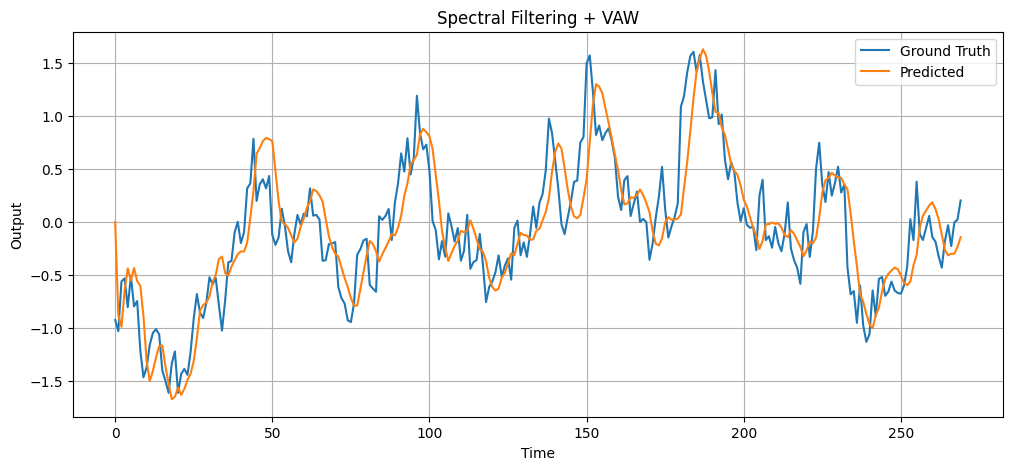

In [13]:
# ============================================================
# 7. Metrics
# ============================================================

mse = np.mean((preds - y_target) ** 2)

print(f"\nOnline MSE: {mse:.6f}")

# ============================================================
# 8. Visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_target, label='Ground Truth')
plt.plot(preds, label='Predicted')

plt.title("Spectral Filtering + VAW")
plt.xlabel("Time")
plt.ylabel("Output")

plt.legend()

plt.grid(True)

plt.show()

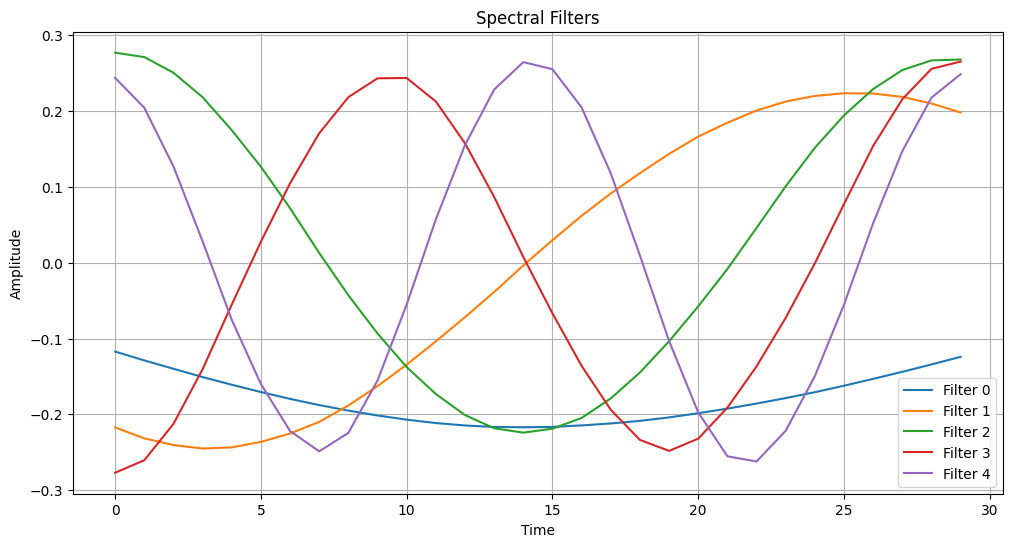

In [14]:

# ============================================================
# 9. Visualizing spectral filters
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(k):
    plt.plot(spectral_filters[:, i], label=f'Filter {i}')

plt.title("Spectral Filters")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.show()